<a href="https://colab.research.google.com/github/SebastianD2/Lab_Biosenales/blob/main/PRACTICA3PARTE2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
!pip install mne

In [5]:
import mne
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats

#Practica 3
Parte 2 -
Análisis de Energía en Señales de EEG para Imaginería Motora
- Juan Jose Lopez Cuadros
- Juan Sebastian Daza Betancourt

#1. Cálculo de la Amplitud Efectiva (RMS)

In [6]:
def calcular_rms(raw_path):

    raw = mne.io.read_raw_edf(raw_path, preload=True, verbose=False)
    raw.filter(7., 30., fir_design='firwin', verbose=False)

    events, _ = mne.events_from_annotations(raw, event_id={'T0': 1, 'T1': 2, 'T2': 3}, verbose=False)

    epochs = mne.Epochs(raw, events, event_id=[2, 3], tmin=-1.0, tmax=4.0,
                        baseline=(None, 0), preload=True, verbose=False)

    epochs_izq = epochs['2']  #  eventos de Mano Izquierda
    epochs_der = epochs['3']  #  eventos de Mano Derecha


    data_izq = epochs_izq.get_data(copy=True)
    rms_epochs_izq = np.sqrt(np.mean(data_izq**2, axis=2))
    rms_izq = np.mean(rms_epochs_izq, axis=0)


    data_der = epochs_der.get_data(copy=True)
    rms_epochs_der = np.sqrt(np.mean(data_der**2, axis=2))
    rms_der = np.mean(rms_epochs_der, axis=0)

    return rms_izq, rms_der, epochs.info


archivo_edf = 'S017R04.edf'


rms_izquierda, rms_derecha, info_canales = calcular_rms(archivo_edf)
print("Ejemplo para un paciente. Matriz con valores de RMS en cada canal clasificada para cada mano.")
print("RMS Mano Izquierda. Cantidad de canales:", len(rms_izquierda))
print(rms_izquierda)
print("RMS Mano Derecha. Cantidad de canales:", len(rms_derecha))
print(rms_derecha)


Ejemplo para un paciente. Matriz con valores de RMS en cada canal clasificada para cada mano.
RMS Mano Izquierda. Cantidad de canales: 64
[4.00011800e-05 2.85309079e-05 2.14888704e-05 1.99884374e-05
 1.97644620e-05 2.08988921e-05 2.89057350e-05 2.42974324e-05
 2.60126707e-05 2.09404055e-05 1.99244192e-05 1.93451051e-05
 1.84856353e-05 1.80433776e-05 2.25826980e-05 2.07312826e-05
 2.01400559e-05 1.95031675e-05 1.88559222e-05 1.91269391e-05
 1.63630860e-05 2.64401751e-05 2.41183469e-05 2.36802171e-05
 3.20324292e-05 2.78007150e-05 2.05059966e-05 2.34884013e-05
 3.25056099e-05 2.76230846e-05 3.31790230e-05 2.40950468e-05
 2.05984289e-05 2.05779830e-05 2.04611299e-05 2.04478960e-05
 2.99908117e-05 2.11706280e-05 3.36659992e-05 2.42700917e-05
 2.17228833e-05 1.31656824e-05 1.95525587e-05 1.95898905e-05
 2.15675307e-05 2.79470515e-05 1.82916679e-05 1.89811162e-05
 1.96523302e-05 1.94763128e-05 1.94940976e-05 1.91437025e-05
 1.81653389e-05 1.70860912e-05 1.69291999e-05 1.90311703e-05
 1.96048

#2. Construcción de la Base de Datos Poblacional

In [10]:
archivos_sujetos = [
    'S017R04.edf', 'S018R04.edf', 'S019R04.edf', 'S020R04.edf', 'S021R04.edf',
    'S022R04.edf', 'S023R04.edf', 'S024R04.edf', 'S025R04.edf', 'S026R04.edf'
]


datos_poblacion_izq = []
datos_poblacion_der = []
nombres_canales = None

for archivo in archivos_sujetos:
    try:
        rms_izq, rms_der, info = calcular_rms(archivo)

        datos_poblacion_izq.append(rms_izq)
        datos_poblacion_der.append(rms_der)

        if nombres_canales is None:
            nombres_canales = info.ch_names

    except Exception as e:
        print(f"Error con el archivo {archivo}: {e}")



df_mano_izquierda = pd.DataFrame(datos_poblacion_izq, columns=nombres_canales, index=archivos_sujetos)
df_mano_derecha = pd.DataFrame(datos_poblacion_der, columns=nombres_canales, index=archivos_sujetos)

print("Aplicamos la funcion anterior para 10 pacientes y la organizamos en un dataframe. Donde sus filas son cada paciente y sus columnas cada canal.")

print("GRUPO MANO IZQUIERDA ")
print(df_mano_izquierda.iloc[:, :])

print("GRUPO MANO DERECHA")
print(df_mano_derecha.iloc[:, :])

Aplicamos la funcion anterior para 10 pacientes y la organizamos en un dataframe. Donde sus filas son cada paciente y sus columnas cada canal.
GRUPO MANO IZQUIERDA 
                 Fc5.      Fc3.      Fc1.      Fcz.      Fc2.      Fc4.  \
S017R04.edf  0.000040  0.000029  0.000021  0.000020  0.000020  0.000021   
S018R04.edf  0.000005  0.000005  0.000005  0.000005  0.000005  0.000005   
S019R04.edf  0.000017  0.000018  0.000018  0.000019  0.000018  0.000019   
S020R04.edf  0.000005  0.000005  0.000005  0.000005  0.000005  0.000004   
S021R04.edf  0.000012  0.000012  0.000012  0.000012  0.000012  0.000011   
S022R04.edf  0.000025  0.000024  0.000025  0.000025  0.000026  0.000026   
S023R04.edf  0.000025  0.000024  0.000023  0.000023  0.000023  0.000024   
S024R04.edf  0.000020  0.000029  0.000017  0.000017  0.000023  0.000033   
S025R04.edf  0.000009  0.000010  0.000009  0.000009  0.000009  0.000009   
S026R04.edf  0.000006  0.000007  0.000006  0.000007  0.000007  0.000009   

         

#3. Identificación de Canales Diferenciales mediante Análisis Estadístico

In [11]:
print("\nANÁLISIS ESTADÍSTICO")

a = 0.05
resultados_estadisticos = []
canales_significativos = []

for canal in df_mano_izquierda.columns:
    datos_izq = df_mano_izquierda[canal].values
    datos_der = df_mano_derecha[canal].values

    # 3.1 Prueba de Normalidad: Shapiro-Wilk
    _, p_shapiro_izq = stats.shapiro(datos_izq)
    _, p_shapiro_der = stats.shapiro(datos_der)

    # Se asume normalidad si el valor p > 0.05 en ambos grupos
    normalidad = (p_shapiro_izq > a) and (p_shapiro_der > a)

    # 3.2 Prueba de Homocedasticidad: Levene
    _, p_levene = stats.levene(datos_izq, datos_der)

    # Se asume varianzas iguales si el valor p > 0.05
    homocedasticidad = (p_levene > a)

    # 3.3 Prueba de Hipótesis
    if normalidad and homocedasticidad:
        # SÍ se cumplen los supuestos paramétricos -> t de Student para muestras independientes
        estadistico, p_valor = stats.ttest_ind(datos_izq, datos_der)
        prueba = "T-Student"
    else:
        # NO se cumplen supuestos -> U de Mann-Whitney (no paramétrica)
        estadistico, p_valor = stats.mannwhitneyu(datos_izq, datos_der, alternative='two-sided')
        prueba = "Mann-Whitney"

    resultados_estadisticos.append({
        'Canal': canal,
        'p-Shapiro_Izq': round(p_shapiro_izq, 4),
        'p-Shapiro_Der': round(p_shapiro_der, 4),
        'Normalidad': 'Sí' if normalidad else 'No',
        'p-Levene': round(p_levene, 4),
        'Homocedasticidad': 'Sí' if homocedasticidad else 'No',
        'Prueba_Usada': prueba,
        'p-valor_Final': round(p_valor, 4)
    })

    if p_valor < a:
        canales_significativos.append((canal, p_valor))

# Resultados estructurados
df_resultados = pd.DataFrame(resultados_estadisticos)


print("\n--- DETALLE DE SUPUESTOS Y PRUEBAS POR CANAL ---")
print(df_resultados.to_string(index=False)) #todas las filas


print("RESULTADOS DE SIGNIFICANCIA (p < 0.05):")
if canales_significativos:
    # de menor a mayor valor p
    canales_significativos.sort(key=lambda x: x[1])
    for c, p in canales_significativos:
        print(f" -> Canal {c}: p-valor = {p:.4f}")
else:
    print(" -> No se encontraron canales con diferencias estadísticamente significativas con p < 0.05.")


ANÁLISIS ESTADÍSTICO

--- DETALLE DE SUPUESTOS Y PRUEBAS POR CANAL ---
Canal  p-Shapiro_Izq  p-Shapiro_Der Normalidad  p-Levene Homocedasticidad Prueba_Usada  p-valor_Final
 Fc5.         0.2680         0.3765         Sí    0.8826               Sí    T-Student         0.9442
 Fc3.         0.1342         0.2311         Sí    0.9735               Sí    T-Student         0.9892
 Fc1.         0.2773         0.2865         Sí    0.9536               Sí    T-Student         0.9517
 Fcz.         0.3502         0.2867         Sí    0.9158               Sí    T-Student         0.9276
 Fc2.         0.1719         0.1606         Sí    0.9339               Sí    T-Student         0.9410
 Fc4.         0.4241         0.4671         Sí    0.9767               Sí    T-Student         0.9632
 Fc6.         0.4415         0.4873         Sí    0.9361               Sí    T-Student         0.9907
 C5..         0.1429         0.2481         Sí    0.9196               Sí    T-Student         0.9889
 C3..     

#4. Resultados y Boxplot


 canal con menor p-valor: F7..


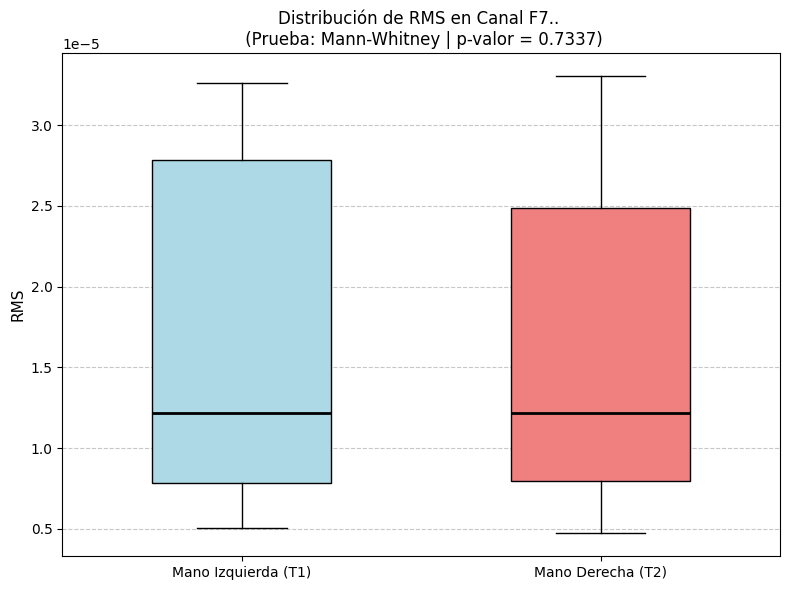

In [14]:
if canales_significativos:
    mejor_canal = canales_significativos[0][0]
    mejor_p_valor = canales_significativos[0][1]
else:
    # el valor p<0.05, se gráfica el más cercano
    mejor_canal = df_resultados.loc[df_resultados['p-valor_Final'].idxmin(), 'Canal']
    mejor_p_valor = df_resultados['p-valor_Final'].min()
    print(f"\n canal con menor p-valor: {mejor_canal}")


plt.figure(figsize=(8, 6))

datos_boxplot = [df_mano_izquierda[mejor_canal], df_mano_derecha[mejor_canal]]

# boxplot
box = plt.boxplot(datos_boxplot, tick_labels=['Mano Izquierda (T1)', 'Mano Derecha (T2)'],
                  patch_artist=True, widths=0.5)

co = ['#add8e6', '#f08080']
for patch, color in zip(box['boxes'], co):
    patch.set_facecolor(color)

for median in box['medians']:
    median.set(color='black', linewidth=2)

plt.title(f'Distribución de RMS en Canal {mejor_canal} \n (Prueba: {df_resultados.loc[df_resultados["Canal"]==mejor_canal, "Prueba_Usada"].values[0]} | p-valor = {mejor_p_valor:.4f})', fontsize=12)
plt.ylabel('RMS', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

#Conclusiones
- Al observar las cajas de ambos grupos (Mano Izquierda y Mano Derecha), se nota que están prácticamente al mismo nivel. Esto significa que la energía captada por el electrodo fue casi igual en ambas tareas.
- Que el mejor canal fuera uno en la frente (F7) y no uno en la zona del movimiento (C3 o C4) sugiere que la diferencia que detectó la estadística es más por ruido o parpadeos que por la intención real de mover las manos.
- Se encontró que cada sujeto tiene niveles de energía muy diferentes (unos muy altos y otros muy bajos). Esta diferencia tan grande entre personas hace que el promedio general se vuelva inestable y sea difícil encontrar un patrón que les sirva a todos por igual.
- Se busco un valor p menor a 0.05 para confirmar que las diferencias no eran por pura suerte. Como ningún canal alcanzó ese número, decimos que no hay evidencia suficiente para separar las dos tareas con este método.